In [108]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [109]:
data = pd.read_csv(r'D:\Machine Learning\Function Transformer\Titanic.csv',usecols=['Age','Fare','Survived'])

In [110]:
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [111]:
data.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [112]:
data['Age']= data['Age'].fillna(data['Age'].mean())

In [113]:
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [114]:
x = data.drop('Survived',axis=1)
y = data['Survived']

In [115]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

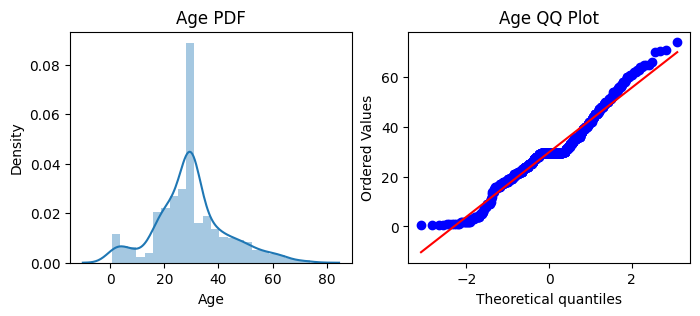

In [116]:
plt.figure(figsize=(8,3))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

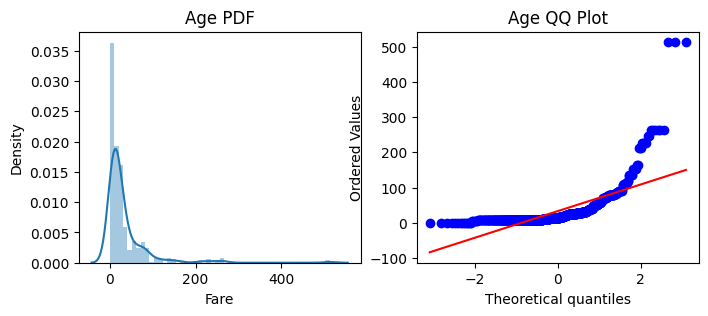

In [117]:
plt.figure(figsize=(8,3))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [118]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [119]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pre = clf1.predict(X_test)
y_pre2 = clf2.predict(X_test)

print("Acurracy Score LR: ",accuracy_score(y_test,y_pre))
print("ACurracy Score DT: ",accuracy_score(y_test,y_pre2))

Acurracy Score LR:  0.664804469273743
ACurracy Score DT:  0.6424581005586593


In [120]:
trf = FunctionTransformer(func=np.log1p)

In [121]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [122]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6983240223463687
Accuracy DT 0.6759776536312849


In [128]:
X_transformed = trf.fit_transform(x)

clf  = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR: ", np.mean(cross_val_score(clf, X_transformed,y,scoring='accuracy',cv=10)))
print("DT: ", np.mean(cross_val_score(clf2, X_transformed,y ,scoring='accuracy', cv=10)))


LR:  0.678027465667915
DT:  0.6633208489388266


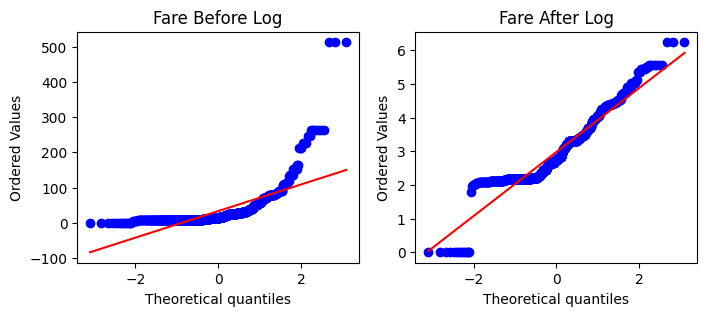

In [131]:
plt.figure(figsize=(8,3))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

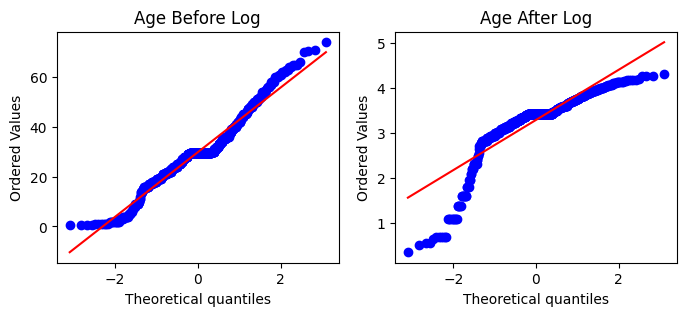

In [132]:
plt.figure(figsize=(8,3))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [133]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [134]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6871508379888268
Accuracy DT 0.6424581005586593


In [136]:
X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6543445692883895
